In [1]:
# Cell 1: Imports, Settings & Helper
%matplotlib inline
import numpy as np
import cv2
import pydicom
import matplotlib.pyplot as plt
from skimage import filters
from skimage.metrics import structural_similarity as ssim

In [2]:
def float_to_uint16(img_float: np.ndarray, max_val: float) -> np.ndarray:
    """
    Linearly rescale a float image (arbitrary range) to [0 .. max_val],
    then cast to uint16.
    """
    # shift to non-negative
    img = img_float - img_float.min()
    # avoid division by zero
    if img.max() > 0:
        img = img / img.max()
    # scale to [0, max_val]
    img16 = np.round(img * max_val).astype(np.uint16)
    return img16

In [3]:
def log_transform(img,max_val):
    img = img.astype(np.float32)
    log_img = np.log1p(img)
    log_img -= log_img.min()
    log_img /= log_img.max()
    log_img *= max_val
    #print(f"[Log] min={log_img.min():.3f}, max={log_img.max():.3f}")
    return log_img.astype(np.uint16)

In [4]:
class DSAProcessor:
    def __init__(self, max_val: float):
        """
        max_val: the maximum pixel value in your DICOM (2**BitsStored - 1).
        """
        self.max_val         = max_val
        self.mask_image      = None  # float32 in [0,1]
        self.contrast_image  = None
        self.registered_mask = None
        self.subtracted_image= None

    def preprocess_images(self):
        """3×3 Gaussian blur → normalize by max_val into [0,1]."""
        self.mask_image     = cv2.GaussianBlur(self.mask_image,    (3,3), 0)
        self.contrast_image = cv2.GaussianBlur(self.contrast_image,(3,3), 0)
        self.mask_image     = self.mask_image.astype(np.float32)    / self.max_val
        self.contrast_image = self.contrast_image.astype(np.float32)/ self.max_val

    def phase_correlation_registration(self):
        f1    = np.fft.fft2(self.mask_image)
        f2    = np.fft.fft2(self.contrast_image)
        cross = (f1 * np.conj(f2)) / np.abs(f1 * np.conj(f2))
        corr  = np.abs(np.fft.ifft2(cross))
        py, px = np.unravel_index(np.argmax(corr), corr.shape)
        dy = py if py < corr.shape[0]//2 else py - corr.shape[0]
        dx = px if px < corr.shape[1]//2 else px - corr.shape[1]
        return dx, dy

    # def feature_based_registration(self):
    #     """Use ORB on CLAHE‐enhanced 8‑bit versions for more robust keypoints."""
    #     m8 = (self.mask_image * 255).astype(np.uint8)
    #     c8 = (self.contrast_image * 255).astype(np.uint8)
    #     clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    #     m8 = clahe.apply(m8)
    #     c8 = clahe.apply(c8)

    #     orb = cv2.ORB_create(nfeatures=1000)
    #     kp1, des1 = orb.detectAndCompute(m8, None)
    #     kp2, des2 = orb.detectAndCompute(c8, None)
    #     print(f"[Feature] ORB keypoints: mask={len(kp1) if kp1 else 0}, contrast={len(kp2) if kp2 else 0}")
    #     if des1 is None or des2 is None:
    #         print("[Feature] No descriptors found")
    #         return None

    #     bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    #     matches = sorted(bf.match(des1, des2), key=lambda m: m.distance)
    #     print(f"[Feature] Raw matches: {len(matches)}")
    #     if len(matches) < 10:
    #         print("[Feature] Not enough matches")
    #         return None

    #     matches = matches[:min(50, len(matches))]
    #     pts1 = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1,1,2)
    #     pts2 = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1,1,2)

    #     # note: positional args for maxIters & confidence
    #     M, inlier_mask = cv2.findHomography(pts1, pts2,
    #                                         cv2.RANSAC,
    #                                         5.0,    # reproj thresh
    #                                         None,   # mask
    #                                         2000,   # maxIters
    #                                         0.99)   # confidence
    #     if inlier_mask is not None:
    #         inliers = int(inlier_mask.sum())
    #         print(f"[Feature] Homography inliers: {inliers}/{len(matches)}")
    #         if inliers < max(10, len(matches) * 0.3):
    #             print("[Feature] Too few inliers, rejecting")
    #             return None

    #     return M

    # def template_matching_registration(self, template_size=64, search_radius=50):
    #     """Center‐block template matching within a ±search_radius window."""
    #     h, w = self.mask_image.shape
    #     cy, cx = h//2, w//2
    #     t = template_size//2
    #     if cy-t < 0 or cy+t > h or cx-t < 0 or cx+t > w:
    #         print("[Template] Template too large")
    #         return 0, 0

    #     templ = self.mask_image[cy-t:cy+t, cx-t:cx+t]
    #     x0 = max(0, cx - t - search_radius)
    #     y0 = max(0, cy - t - search_radius)
    #     x1 = min(w, cx + t + search_radius)
    #     y1 = min(h, cy + t + search_radius)
    #     region = self.contrast_image[y0:y1, x0:x1]

    #     res = cv2.matchTemplate(region, templ, cv2.TM_CCOEFF_NORMED)
    #     _, conf, _, loc = cv2.minMaxLoc(res)
    #     print(f"[Template] Match confidence: {conf:.3f}")

    #     dx = (x0 + loc[0]) - (cx - t)
    #     dy = (y0 + loc[1]) - (cy - t)
    #     return dx, dy

    def optical_flow_registration(self):
        """Track corners and compute median displacement, with error filtering."""
        h, w = self.mask_image.shape
        m8 = (self.mask_image * 255).astype(np.uint8)
        c8 = (self.contrast_image * 255).astype(np.uint8)

        corners = cv2.goodFeaturesToTrack(m8, maxCorners=200,
                                          qualityLevel=0.01, minDistance=10)
        cnt = 0 if corners is None else len(corners)
        if cnt < 10:
            print(f"[OptFlow] Insufficient corners: {cnt}")
            return None
        print(f"[OptFlow] Tracking {cnt} corners")

        pts0 = corners.reshape(-1,1,2)
        lk_params = dict(winSize=(15,15), maxLevel=2,
                         criteria=(cv2.TERM_CRITERIA_EPS|cv2.TERM_CRITERIA_COUNT,
                                   10,0.03))
        pts1, st, err = cv2.calcOpticalFlowPyrLK(m8, c8, pts0, None, **lk_params)
        pts1 = pts1.reshape(-1,2); st = st.reshape(-1); err = err.reshape(-1)
        good = (st==1) & (err <= np.percentile(err[st==1],75))
        pts0g = pts0.reshape(-1,2)[good]
        pts1g = pts1[good]
        print(f"[OptFlow] Good tracks: {len(pts0g)}")
        if len(pts0g) < 10:
            return None

        disp = pts1g - pts0g
        dx, dy = np.median(disp, axis=0)
        if abs(dx) > w*0.2 or abs(dy) > h*0.2:
            print(f"[OptFlow] Displacement too large: dx={dx:.1f}, dy={dy:.1f}")
            return None

        return float(dx), float(dy)

    def apply_shift(self, img, dx, dy):
        M = np.float32([[1,0,dx],[0,1,dy]])
        return cv2.warpAffine(img, M, (img.shape[1], img.shape[0]))

    def apply_homography(self, img, H):
        return cv2.warpPerspective(img, H, (img.shape[1], img.shape[0]))

    def multi_method_registration(self):
        """
        Try all four methods, log each, pick best by SSIM (data_range=1.0),
        and store self.registered_mask.
        """
        results = []
        methods = [
            ("phase_correlation", self.phase_correlation_registration),
            ("optical_flow", self.optical_flow_registration),
        ]
        for name, func in methods:
            try:
                res = func()
                if res is None:
                    print(f"[{name}] returned None")
                    continue

                
                dx, dy = res
                print(f"[{name}] shift: dx={dx}, dy={dy}")
                reg = self.apply_shift(self.mask_image, dx, dy)

                score = ssim(reg, self.contrast_image, data_range=1.0)
                print(f"[{name}] SSIM: {score:.4f}")
                results.append((name, reg, score))
            except Exception as e:
                print(f"[{name}] failed: {e}")

        if not results:
            print(">> All methods failed; using original mask")
            self.registered_mask = self.mask_image
            return self.mask_image, "none", 0.0

        best_name, best_reg, best_score = max(results, key=lambda x: x[2])
        self.registered_mask = best_reg
        print(f">> Best: {best_name}, SSIM={best_score:.4f}")
        return best_reg, best_name, best_score

    def perform_subtraction(self, method='log'):
        if method == 'log':
            sub = (np.log(self.contrast_image + 1e-10)
                   - np.log(self.registered_mask + 1e-10))
        else:
            sub = self.contrast_image - self.registered_mask
        self.subtracted_image = sub
        return sub

    def enhance_vessels(self, sigma=1.0):
        if self.subtracted_image is None:
            raise ValueError("Call perform_subtraction first")
        e = filters.gaussian(self.subtracted_image, sigma=sigma)
        lo, hi = np.percentile(e, [2, 98])
        e = np.clip(e, lo, hi)
        return (e - e.min()) / (e.max() - e.min())

    def visualize_results(self, results, max_val):
        """2×3 grid—works with 16-bit inputs if you supply vmin/vmax."""
        fig, ax = plt.subplots(2, 3, figsize=(15,10))
        ax[0,0].imshow(results['original_mask'],     cmap='gray', vmin=0, vmax=max_val)
        ax[0,0].set_title("Original Mask");    ax[0,0].axis('off')
       
        ax[0,1].imshow(results['original_contrast'], cmap='gray', vmin=0, vmax=max_val)
        ax[0,1].set_title("Original Contrast"); ax[0,1].axis('off')
        
        ax[0,2].imshow(results['registered_mask'],  cmap='gray', vmin=0, vmax=max_val)
        ax[0,2].set_title(f"Registered Mask\n({results['registration_method']})"); ax[0,2].axis('off')
        
        ax[1,0].imshow(results['subtracted'], cmap='gray', vmin=0, vmax=max_val)
        ax[1,0].set_title("Subtracted Image"); ax[1,0].axis('off')
        
        ax[1,1].imshow(results['enhanced'],  cmap='gray', vmin=0, vmax=max_val)
        ax[1,1].set_title("Enhanced Vessels"); ax[1,1].axis('off')
        
        diff = np.abs(results['registered_mask'].astype(np.int32)
                      - results['original_contrast'].astype(np.int32))
        
        ax[1,2].imshow(diff, cmap='seismic', vmin=0, vmax=max_val)
        ax[1,2].set_title(f"Registration Quality\n(SSIM: {results['registration_score']:.3f})"); ax[1,2].axis('off')
        
        plt.tight_layout()
        plt.show()

In [5]:
def process_dicom_frame_16bit(dcm_path: str,
                              contrast_idx: int,
                              subtraction_method: str = 'log'):
    """
    Load a multi-frame DICOM, take frame 0 as mask and frame contrast_idx
    as contrast, run the DSA pipeline, and return all results in 16‑bit.
    """
    ds = pydicom.dcmread(dcm_path)
    frames = ds.pixel_array.astype(np.float32)
    max_val = float(2**ds.BitsStored - 1)
    n = frames.shape[0]
    if not (1 <= contrast_idx < n):
        raise IndexError(f"contrast_idx must be in [1..{n-1}]")

    orig_mask     = frames[2].round().astype(np.uint16)
    orig_contrast = frames[contrast_idx].round().astype(np.uint16)

    dsa = DSAProcessor(max_val)
    dsa.mask_image     = frames[2]
    dsa.contrast_image = frames[contrast_idx]
    dsa.preprocess_images()

    reg_float, method, score = dsa.multi_method_registration()
    dsa.registered_mask = reg_float

    sub_float = dsa.perform_subtraction(method=subtraction_method)
    enh_float = dsa.enhance_vessels()

    return {
        'original_mask':      log_transform(orig_mask,max_val),
        'original_contrast':  log_transform(orig_contrast,max_val),
        'registered_mask':    float_to_uint16(reg_float, max_val),
        'subtracted':         float_to_uint16(sub_float, max_val),
        'enhanced':           float_to_uint16(enh_float, max_val),
        'registration_method':method,
        'registration_score': score,
        'max_val':            max_val
    }

[phase_correlation] shift: dx=0, dy=0
[phase_correlation] SSIM: 0.9988
[OptFlow] Tracking 200 corners
[OptFlow] Good tracks: 150
[optical_flow] shift: dx=0.18560028076171875, dy=0.5523433685302734
[optical_flow] SSIM: 0.9986
>> Best: phase_correlation, SSIM=0.9988


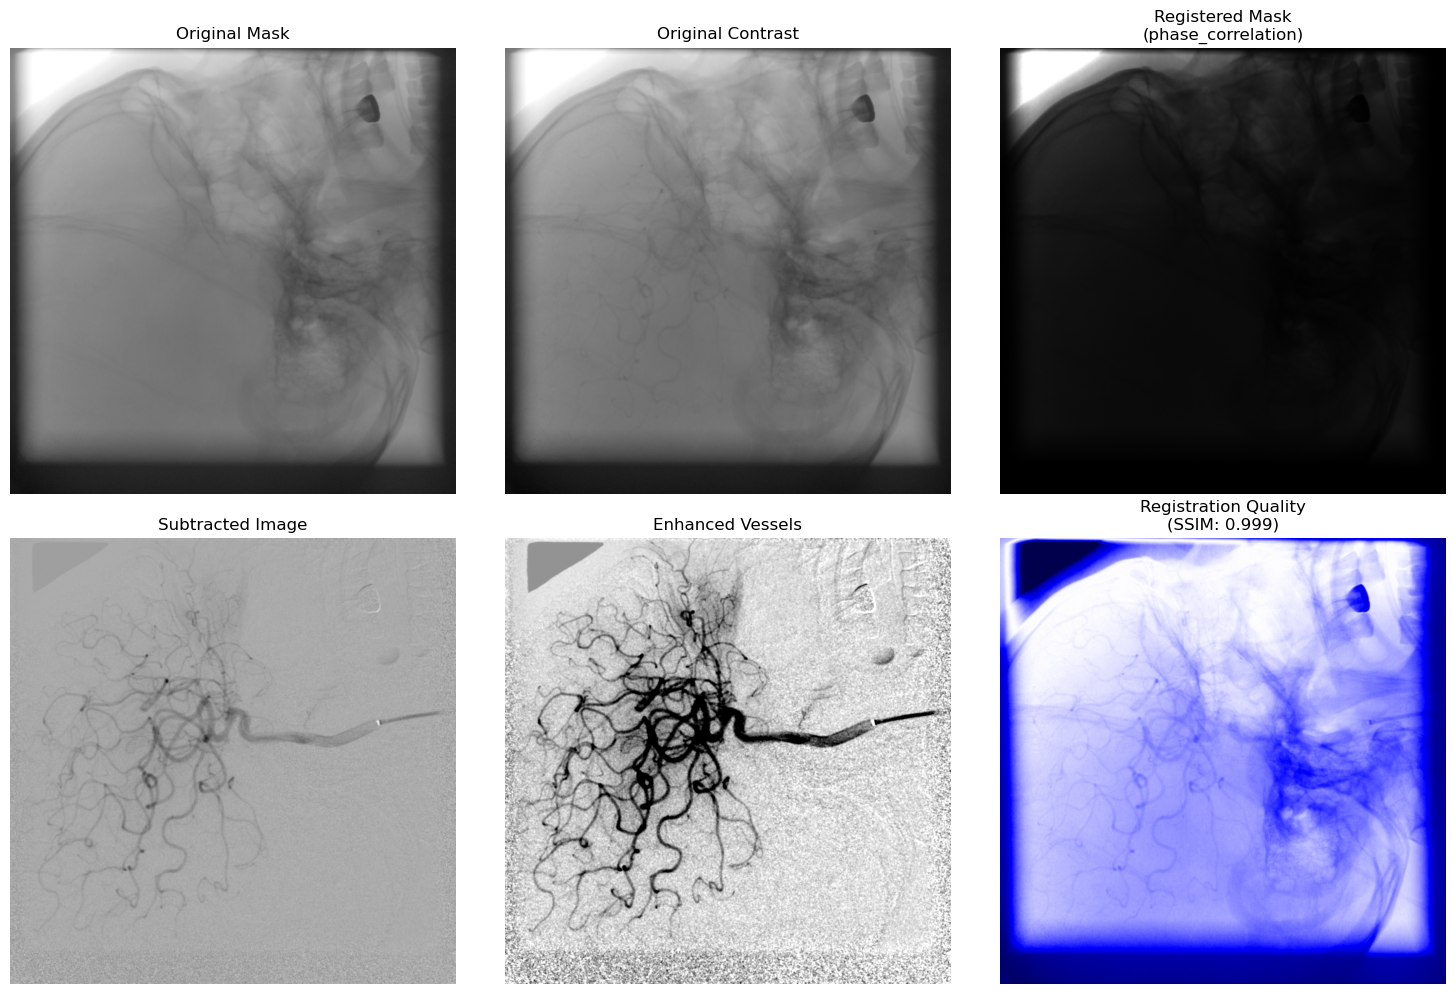

Method: phase_correlation, SSIM=0.999


In [8]:
# Cell 4: Run & visualize
dcm_file     = '/media/iitpl_susmita/DATA/MAHAVEER HOSPITAL/09-10-2024 MAHAVEER HOSPITAL/SBM-087-24/1.2.826.0.1.3680043.2.1330.2640165.2410060034050006.5.1460_Raw.dcm'  # your file here
contrast_idx = 10

results = process_dicom_frame_16bit(dcm_file, contrast_idx, subtraction_method='log')

# Display all 6 panels in 16-bit with correct vmin/vmax
DSAProcessor(results['max_val']).visualize_results(results, results['max_val'])

print(f"Method: {results['registration_method']}, SSIM={results['registration_score']:.3f}")


[phase_correlation] shift: dx=0, dy=0
[phase_correlation] SSIM: 0.9669
[OptFlow] Tracking 200 corners
[optical_flow] failed: index -1 is out of bounds for axis 0 with size 0
>> Best: phase_correlation, SSIM=0.9669


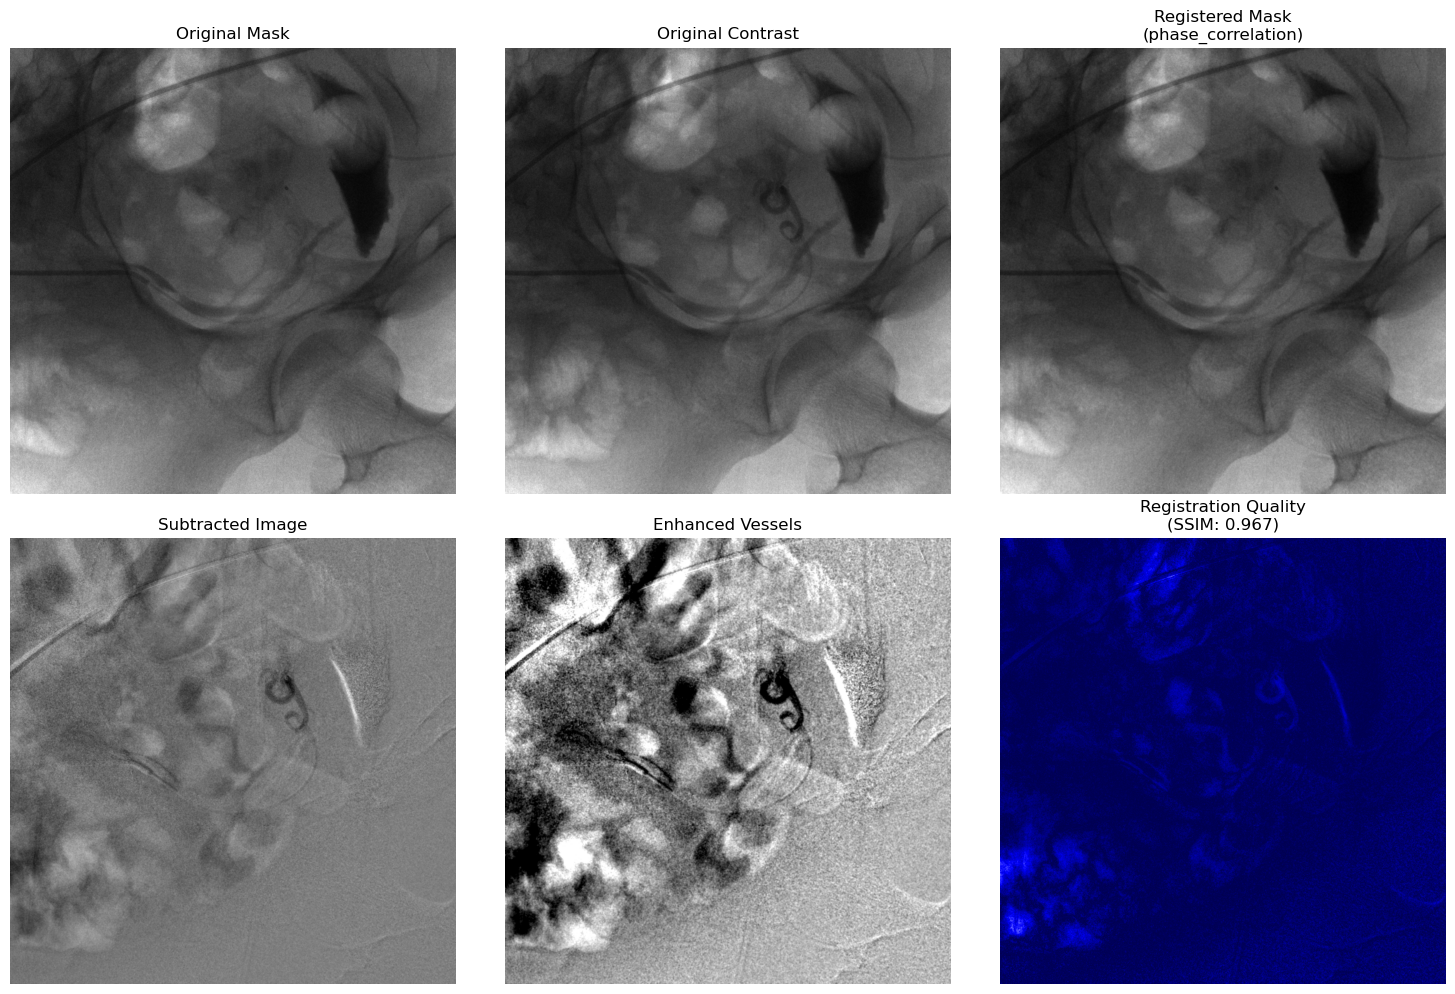

Method=phase_correlation, SSIM=0.9669


In [6]:
# Cell 4: Run & visualize
dcm_file     = '/media/iitpl_susmita/DATA/Auto_pixel_shift/1.2.826.0.1.3680043.2.1330.2640285.2412181804220009.5.984_Raw.dcm'  # your file here
contrast_idx = 30

results     = process_dicom_frame_16bit(dcm_file, contrast_idx, 'log')
DSAProcessor(results['max_val']).visualize_results(results, results['max_val'])
print(f"Method={results['registration_method']}, SSIM={results['registration_score']:.4f}")

In [ ]:
def process_dicom_frame_16bit(dcm_path: str,
                              contrast_idx: int,
                              subtraction_method: str = 'log'):
    """
    Load a multi-frame DICOM, take frame 0 as mask and frame contrast_idx
    as contrast, run the DSA pipeline, and return all results in 16‑bit.
    """
    ds = pydicom.dcmread(dcm_path)
    frames = ds.pixel_array.astype(np.float32)
    max_val = float(2**ds.BitsStored - 1)
    n = frames.shape[0]
    if not (1 <= contrast_idx < n):
        raise IndexError(f"contrast_idx must be in [1..{n-1}]")

    orig_mask     = frames[2].round().astype(np.uint16)
    orig_contrast = frames[contrast_idx].round().astype(np.uint16)

    dsa = DSAProcessor(max_val)
    dsa.mask_image     = frames[2]
    dsa.contrast_image = frames[contrast_idx]
    dsa.preprocess_images()

    reg_float, method, score = dsa.multi_method_registration()
    dsa.registered_mask = reg_float

    sub_float = dsa.perform_subtraction(method=subtraction_method)
    enh_float = dsa.enhance_vessels()

    return {
        'original_mask':      log_transform(orig_mask,max_val),
        'original_contrast':  log_transform(orig_contrast,max_val),
        'registered_mask':    float_to_uint16(reg_float, max_val),
        'subtracted':         float_to_uint16(sub_float, max_val),
        'enhanced':           float_to_uint16(enh_float, max_val),
        'registration_method':method,
        'registration_score': score,
        'max_val':            max_val
    }

In [1]:
# Cell 1: Imports & enhancement helper
%matplotlib inline
import numpy as np
import cv2
import pydicom
import matplotlib.pyplot as plt
from skimage import filters
from skimage.metrics import structural_similarity as ssim
from pydicom.uid import ExplicitVRLittleEndian

def enhance_vessels(img: np.ndarray, sigma: float = 1.0) -> np.ndarray:
    """
    img: float image in [0,1]
    Returns: vessel‑enhanced image in [0,1]
    """
    e = filters.gaussian(img, sigma=sigma)
    lo, hi = np.percentile(e, [2, 98])
    e = np.clip(e, lo, hi)
    return (e - e.min()) / (e.max() - e.min())



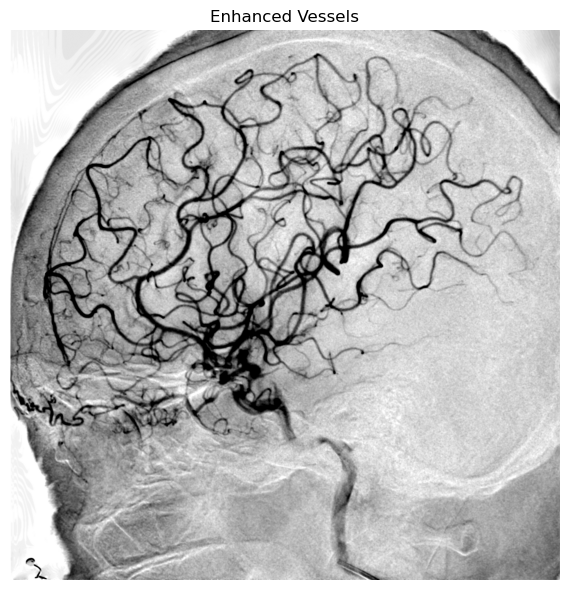

In [5]:

# Cell 2: Load + normalize one frame + enhance + plot
dcm_path     = '/media/iitpl_susmita/DATA/Auto_pixel_shift/1.2.826.1.3680043.2.389.3113001.20170901162043327.0072.dcm'
# 1) Read DICOM
ds     = pydicom.dcmread(dcm_path)
frames = ds.pixel_array.astype(np.float32)      # raw pixel values
max_val = float(2**ds.BitsStored - 1)           # e.g. 4095 or 65535

# 2) Choose your “mask” (frame 0) or any frame
mask_frame = frames[39]

# 3) Normalize into [0,1]
mask_norm = mask_frame / max_val

# 4) Enhance vessels
enhanced = enhance_vessels(mask_norm, sigma=1.0)

# 5) Display
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(enhanced, cmap='gray', vmin=0, vmax=1)
ax.set_title('Enhanced Vessels')
ax.axis('off')
plt.tight_layout()
plt.show()


In [5]:
# Cell 2: DICOM‑loop enhancer

def enhance_dicom_loop(in_path: str,
                       out_path: str,
                       sigma: float = 1.0):
    """
    Read a multi-frame DICOM, enhance each frame, and save a new DICOM.
    """
    # 1) Load original
    ds = pydicom.dcmread(in_path)
    frames = ds.pixel_array.astype(np.float32)  # shape = (N, H, W)
    bits    = ds.BitsStored
    max_val = float(2**bits - 1)
    
    # 2) Normalize each frame to [0,1]
    norm = frames / max_val
    
    # 3) Enhance every frame
    enhanced = np.stack([enhance_vessels(norm[i], sigma) for i in range(norm.shape[0])])
    
    # 4) Convert back to uint16
    enhanced_uint16 = (enhanced * max_val).round().astype(np.uint16)
    
    # 5) Build new dataset
    out = ds.copy()
    out.file_meta.TransferSyntaxUID = ExplicitVRLittleEndian
    
    # Update pixel data and related fields
    out.PixelData         = enhanced_uint16.tobytes()
    out.Rows, out.Columns = enhanced_uint16.shape[1], enhanced_uint16.shape[2]
    out.NumberOfFrames    = enhanced_uint16.shape[0]
    out.BitsStored        = bits
    out.BitsAllocated     = 16
    out.HighBit           = bits - 1
    out.PixelRepresentation = 0  # unsigned
    # If your original had PlanarConfiguration or SamplesPerPixel=1, these stay the same
    
    # 6) Save
    pydicom.filewriter.dcmwrite(out_path, out)
    print(f"Saved enhanced loop ➔ {out_path}")


In [6]:
# Cell 3: Run it!

in_dcm  = '/media/iitpl_susmita/DATA/Auto_pixel_shift/1.2.826.1.3680043.2.389.3113001.20170901162043327.0072.dcm'
out_dcm = '/media/iitpl_susmita/DATA/Auto_pixel_shift/your_output_enhanced_loop.dcm'
enhance_dicom_loop(in_dcm, out_dcm, sigma=1.0)


Saved enhanced loop ➔ /media/iitpl_susmita/DATA/Auto_pixel_shift/your_output_enhanced_loop.dcm


In [4]:
# Cell 2: Enhance + stack DICOM loop side-by-side
def enhance_and_stack_dicom_loop(in_path: str,
                                 out_path: str,
                                 sigma: float = 1.0):
    """
    Read a multi-frame DICOM, enhance each frame, horizontally stack
    original and enhanced side-by-side, and save a new DICOM.
    """
    # 1) Load original
    ds       = pydicom.dcmread(in_path)
    frames   = ds.pixel_array.astype(np.float32)  # shape = (N, H, W)
    bits     = ds.BitsStored
    max_val  = float(2**bits - 1)
    N, H, W  = frames.shape

    # 2) Original uint16 frames
    orig_uint16 = frames.round().astype(np.uint16)

    # 3) Normalize to [0,1] for enhancement
    norm = frames / max_val

    # 4) Enhance every frame
    enhanced = np.stack([enhance_vessels(norm[i], sigma) for i in range(N)])

    # 5) Convert enhanced back to uint16
    enh_uint16 = (enhanced * max_val).round().astype(np.uint16)

    # 6) Stack original & enhanced side-by-side
    stacked = np.stack([np.hstack((orig_uint16[i], enh_uint16[i])) for i in range(N)])
    # stacked.shape == (N, H, 2*W)

    # 7) Build new DICOM
    out = ds.copy()
    out.file_meta.TransferSyntaxUID = ExplicitVRLittleEndian

    out.PixelData           = stacked.tobytes()
    out.NumberOfFrames      = N
    out.Rows                = H
    out.Columns             = 2 * W
    out.BitsAllocated       = 16
    out.BitsStored          = bits
    out.HighBit             = bits - 1
    out.PixelRepresentation = 0  # unsigned
    # SamplesPerPixel, PhotometricInterpretation, etc., stay as in original

    # 8) Write new file
    pydicom.filewriter.dcmwrite(out_path, out)
    print(f"Saved side‑by‑side enhanced loop → {out_path}")


In [5]:
# Cell 3: Run the side-by-side enhancer
in_dcm  = '/media/iitpl_susmita/DATA/Noise_reduction/1.2.826.0.1.3680043.2.1330.2640034.2112071722040002.5.801.dcm'
out_dcm = '/media/iitpl_susmita/DATA/Auto_pixel_shift/your_output_enhanced_loop_stacked3.dcm'
enhance_and_stack_dicom_loop(in_dcm, out_dcm, sigma=1.0)


Saved side‑by‑side enhanced loop → /media/iitpl_susmita/DATA/Auto_pixel_shift/your_output_enhanced_loop_stacked3.dcm
